In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import pandas as pd
from analysis_tools.workflows.evaluation_flow import evaluation_flow
from analysis_tools.workflows.BDT_pipeline import run_bdt_pipeline
from analysis_tools.namings.BDT_feature_naming import BDT_feature_name_change
from analysis_tools.BDT_tools.Testset_preparation import create_learning_input,annotate_labels
from analysis_tools.BDT_tools.BDT_evaluation import find_best_two_bdt_thresholds,plot_bdt_threshold_scan
from analysis_tools.workflows.prediction_flow import prediction_flow,predict_scores
from analysis_tools.my_selectors.apply_selection import apply_selection


/data/user/tvaneede/software/py_venvs/py3-v4.4.1_reco-v1.1.0/lib/python3.12/site-packages/xgboost/core.py:377: FutureWarning: Your system has an old version of glibc (< 2.28). We will stop supporting Linux distros with glibc older than 2.28 after **May 31, 2025**. Please upgrade to a recent Linux distro (with glibc >= 2.28) to use future versions of XGBoost.
Note: You have installed the 'manylinux2014' variant of XGBoost. Certain features such as GPU algorithms or federated learning are not available. To use these features, please upgrade to a recent Linux distro with glibc 2.28+, and install the 'manylinux_2_28' variant.
  warnings.warn(


In [13]:
model_configs = [
  {
    'name':'bdt1',
    'sig_mask': lambda df: 
                   (df['sig_bdt1']) & 
                   (df['MCTruth_Cascade_Distance_value'] > 10),
    'bg_mask' : 'bg_bdt1'  
  },
  {
    'name':'bdt2',
    'sig_mask': lambda df: 
                   (df['sig_bdt1']) & 
                   (df['MCTruth_Cascade_Distance_value'] > 10),
    'bg_mask' :'bg_bdt2'
  }
]

In [14]:
df_train = pd.read_hdf("/data/user/zchen/data_process/test_sets/Finallevel_nugen_22612-22645.h5")
df_test = pd.read_hdf("/data/user/zchen/data_process/test_sets/Finallevel_nugen_22684-22692.h5")

features_list = ['Taupede_ftpMonoDiff_rlogl_value',
                'Taupede_ftp_Asymmetry_value',
                'Taupede_ftp_Distance_value',
                'Taupede_ftp_1Particles_energy',
                'Taupede_ftp_2Particles_energy',
                'cscdSBU_LE_bdt_input_cscdSBU_MonopodFit4_noDC_zenith',
                'cscdSBU_LE_bdt_input_cscdSBU_MonopodFit4_noDC_Delay_ice_value',
                'CVStatistics_q_max_doms',
                'cscdSBU_LE_bdt_input_cscdSBU_VertexRecoDist_CscdLLh',
                'cscdSBU_MonopodFit4_noDC_energy',
                'cscdSBU_LE_bdt_input_cscdSBU_Qtot_HLC_log_value',
                'Taupede_ftpFitParams_rlogl',
                'cscdSBU_MonopodFit4_noDCFitParams_rlogl']

In [15]:
Taupede_name = 'Taupede_ftp'
precut_dict = {'cscdSBU_MonopodFit4_noDC_energy':('>', 10**4.5),
                  'cscdSBU_Qtot_HLC_value':('>', 10**3),
                  f'{Taupede_name}_Distance_value':[('>', 10),('<', 400)],
                  'cscdSBU_LE_bdt_input_cscdSBU_I3XYScale_noDC_value':('<', 0.9),
                  'cscdSBU_MonopodFit4_noDC_z':{'and':[('>', -500),('<', 500)],
                                                'or':[('>', -50), ('<', -150)]},
                  f'{Taupede_name}_1Particles_x':[('>', -500),('<', 500)],
                  f'{Taupede_name}_1Particles_y':[('>', -500),('<', 500)],
                  f'{Taupede_name}_1Particles_z':{'and':[('>', -500),('<', 500)],
                                                  'or':[('>', -50), ('<', -150)]},
                  f'{Taupede_name}_2Particles_x':[('>', -500),('<', 500)],
                  f'{Taupede_name}_2Particles_y':[('>', -500),('<', 500)],
                  f'{Taupede_name}_2Particles_z':{'and':[('>', -500),('<', 500)],
                                                  'or':[('>', -50), ('<', -150)]},
}

df_train_precut = apply_selection(df_train,precut_dict)
df_test_precut = apply_selection(df_test,precut_dict)

# Training

Fitting 5 folds for each of 96 candidates, totalling 480 fits


/data/user/tvaneede/software/py_venvs/py3-v4.4.1_reco-v1.1.0/lib/python3.12/site-packages/xgboost/core.py:377: FutureWarning: Your system has an old version of glibc (< 2.28). We will stop supporting Linux distros with glibc older than 2.28 after **May 31, 2025**. Please upgrade to a recent Linux distro (with glibc >= 2.28) to use future versions of XGBoost.
Note: You have installed the 'manylinux2014' variant of XGBoost. Certain features such as GPU algorithms or federated learning are not available. To use these features, please upgrade to a recent Linux distro with glibc 2.28+, and install the 'manylinux_2_28' variant.
  warnings.warn(
/data/user/tvaneede/software/py_venvs/py3-v4.4.1_reco-v1.1.0/lib/python3.12/site-packages/xgboost/core.py:377: FutureWarning: Your system has an old version of glibc (< 2.28). We will stop supporting Linux distros with glibc older than 2.28 after **May 31, 2025**. Please upgrade to a recent Linux distro (with glibc >= 2.28) to use future versions of X

Saved best model to /data/user/tvaneede/GlobalFit/reco_processing/bdt/training/train_output/bdt1_model.pkl
Trained bdt1, saved to /data/user/tvaneede/GlobalFit/reco_processing/bdt/training/train_output/bdt1_model.pkl


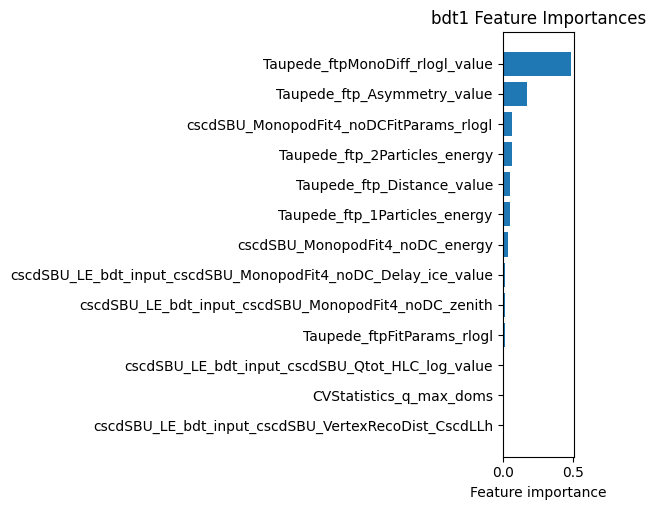

Saved feature importances to /data/user/tvaneede/GlobalFit/reco_processing/bdt/training/train_output/bdt1_importances.png
Fitting 5 folds for each of 96 candidates, totalling 480 fits
Saved best model to /data/user/tvaneede/GlobalFit/reco_processing/bdt/training/train_output/bdt2_model.pkl
Trained bdt2, saved to /data/user/tvaneede/GlobalFit/reco_processing/bdt/training/train_output/bdt2_model.pkl


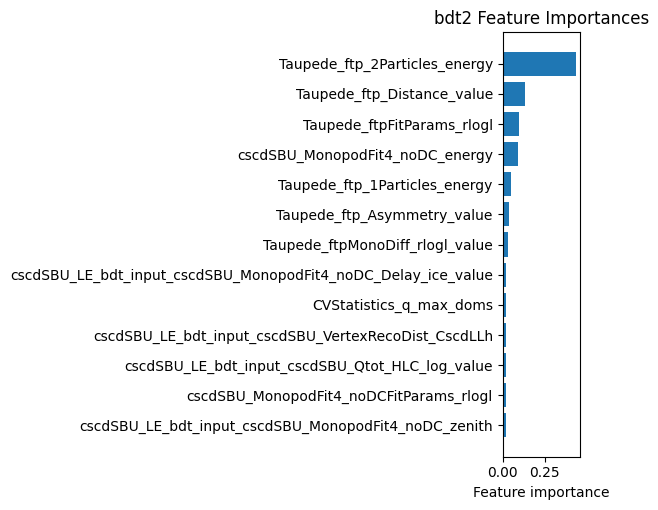

Saved feature importances to /data/user/tvaneede/GlobalFit/reco_processing/bdt/training/train_output/bdt2_importances.png

=== Pre-BDT rates ===
Calculating rates for flavor: nue
Raw event count: 36970
[weight] rate        = 2.60105
[weight] uncertainty = 0.0271483
Calculating rates for flavor: numu
Raw event count: 21805
[weight] rate        = 1.75571
[weight] uncertainty = 0.0472705
Calculating rates for flavor: nutau
Raw event count: 45486
[weight] rate        = 1.64442
[weight] uncertainty = 0.0153954


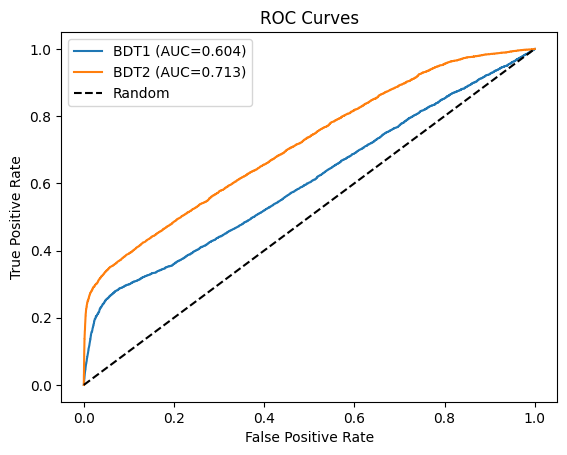

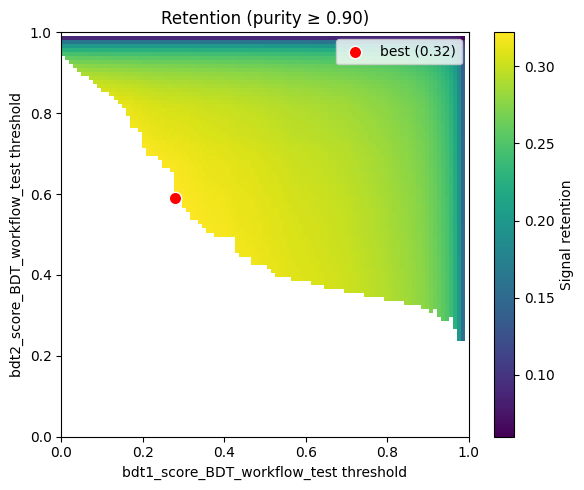


=== Post-BDT rates ===
Calculating post-BDT rates for flavor: nue
Raw event count: 602
[weight] rate        = 0.0242822
[weight] uncertainty = 0.00203967
Calculating post-BDT rates for flavor: numu
Raw event count: 1491
[weight] rate        = 0.0343053
[weight] uncertainty = 0.00401603
Calculating post-BDT rates for flavor: nutau
Raw event count: 23438
[weight] rate        = 0.52944
[weight] uncertainty = 0.00720887


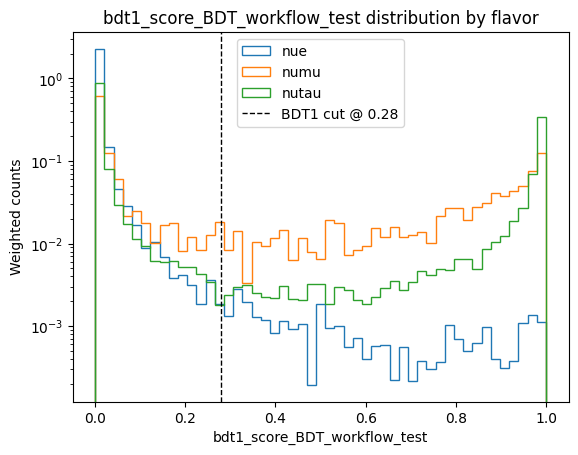

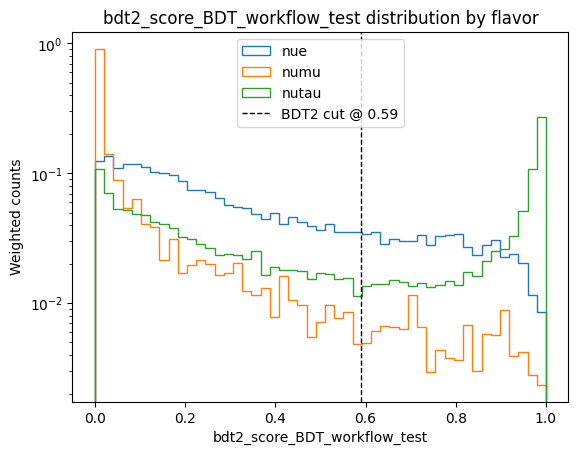

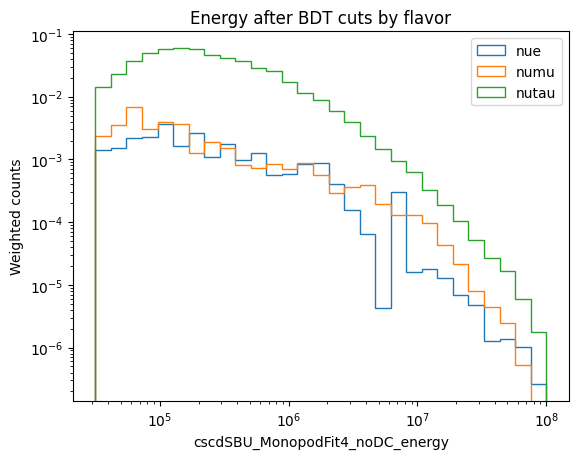


Final purity: 0.900, efficiency: 0.322


In [7]:

model_name = 'BDT_workflow_test'

models, summary = run_bdt_pipeline(
    df_train_precut, df_test_precut,
    global_precuts = None,
    model_configs  = model_configs,
    features       = features_list,
    weight_col     = 'weight',
    purity_target  = 0.90,
    score_cols     = [f'bdt1_score_{model_name}',f'bdt2_score_{model_name}'],
    train_outdir   = '/data/user/tvaneede/GlobalFit/reco_processing/bdt/training/train_output/',
    eval_outdir    = '/data/user/tvaneede/GlobalFit/reco_processing/bdt/training/eval_output/'
) 

# Prediction

In [16]:
import pickle
model_name = 'BDT_workflow_test'
model_indir = '/data/user/tvaneede/GlobalFit/reco_processing/bdt/training/train_output/'
with open(model_indir+'bdt1_model.pkl',"rb") as f:
        bdt1 = pickle.load(f)
with open(model_indir+'bdt2_model.pkl',"rb") as f:
        bdt2 = pickle.load(f)
        
models = {'bdt1': bdt1, 'bdt2': bdt2}
thresholds = {'bdt1_score': 0.28, 'bdt2_score': 0.59}

df_with_scores = prediction_flow(
    df_test_precut,
    models,
    features_list,
    thresholds=thresholds
)


=== Pre-BDT rates ===
Calculating rates for flavor: nue
Raw event count: 36970
[weight] rate        = 2.60105
[weight] uncertainty = 0.0271483
Calculating rates for flavor: numu
Raw event count: 21805
[weight] rate        = 1.75571
[weight] uncertainty = 0.0472705
Calculating rates for flavor: nutau
Raw event count: 45486
[weight] rate        = 1.64442
[weight] uncertainty = 0.0153954


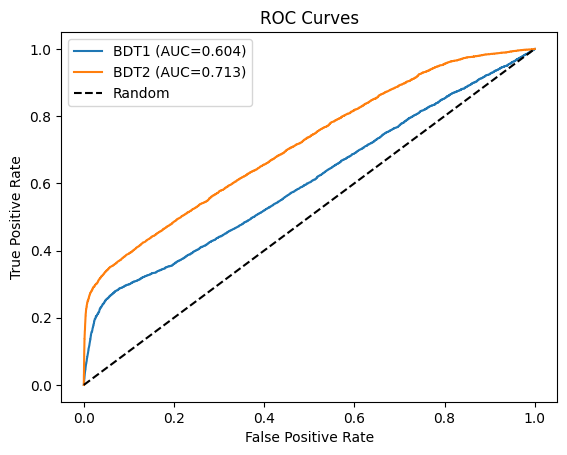

saving roc curves


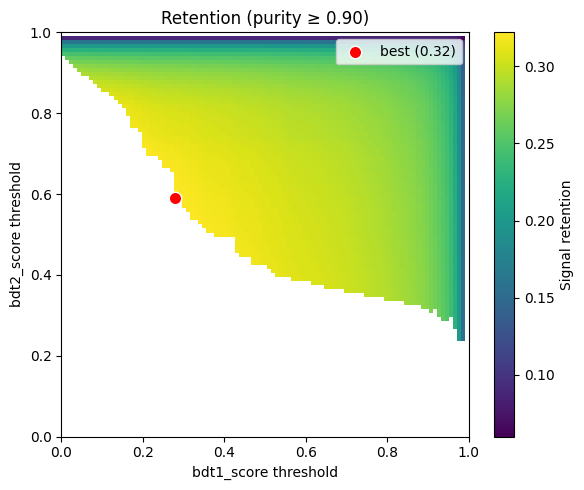


=== Post-BDT rates ===
Calculating post-BDT rates for flavor: nue
Raw event count: 602
[weight] rate        = 0.0242822
[weight] uncertainty = 0.00203967
Calculating post-BDT rates for flavor: numu
Raw event count: 1491
[weight] rate        = 0.0343053
[weight] uncertainty = 0.00401603
Calculating post-BDT rates for flavor: nutau
Raw event count: 23438
[weight] rate        = 0.52944
[weight] uncertainty = 0.00720887


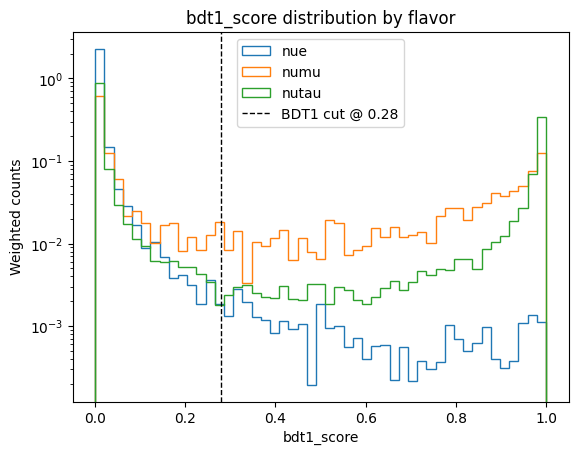

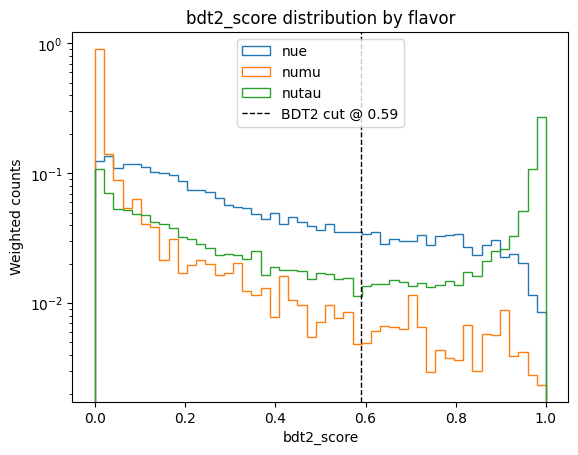

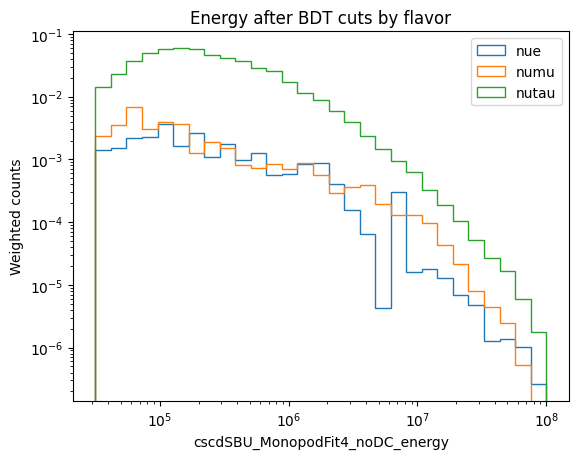


Final purity: 0.900, efficiency: 0.322


In [22]:
from analysis_tools.workflows.evaluation_flow import evaluation_flow

df_eval = df_with_scores

summary = evaluation_flow(
    df_eval, 
    model1 = bdt1,
    model2 = bdt2, 
    features = features_list,
    weight_col = 'weight',
    precut_criteria=precut_dict,
    purity_target=0.90,
    output_dir='/data/user/tvaneede/GlobalFit/reco_processing/bdt/training/retraining_thijs/'
)

Lets import zheyang model

In [25]:
model_name = 'BDT_workflow_test'
model_indir = '/data/user/tvaneede/GlobalFit/reco_processing/bdt/training/ftp_13features/'
with open(model_indir+'bdt1_model.pkl',"rb") as f:
        bdt1 = pickle.load(f)
with open(model_indir+'bdt2_model.pkl',"rb") as f:
        bdt2 = pickle.load(f)
        
models = {'bdt1': bdt1, 'bdt2': bdt2}
thresholds = {'bdt1_score': 0.27, 'bdt2_score': 0.59}

df_with_scores = prediction_flow(
    df_test_precut,
    models,
    features_list,
    thresholds=thresholds
)


=== Pre-BDT rates ===
Calculating rates for flavor: nue
Raw event count: 36970
[weight] rate        = 2.60105
[weight] uncertainty = 0.0271483
Calculating rates for flavor: numu
Raw event count: 21805
[weight] rate        = 1.75571
[weight] uncertainty = 0.0472705
Calculating rates for flavor: nutau
Raw event count: 45486
[weight] rate        = 1.64442
[weight] uncertainty = 0.0153954


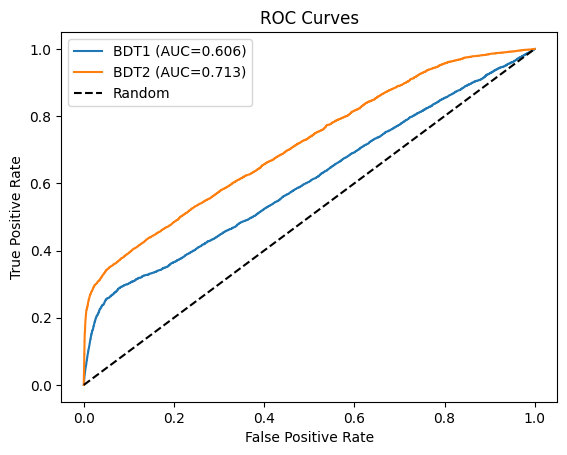

saving roc curves


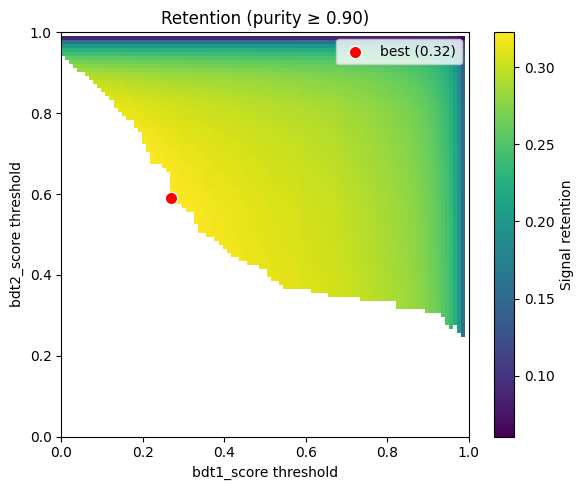


=== Post-BDT rates ===
Calculating post-BDT rates for flavor: nue
Raw event count: 621
[weight] rate        = 0.0251903
[weight] uncertainty = 0.00205476
Calculating post-BDT rates for flavor: numu
Raw event count: 1481
[weight] rate        = 0.0336443
[weight] uncertainty = 0.0037869
Calculating post-BDT rates for flavor: nutau
Raw event count: 23449
[weight] rate        = 0.530532
[weight] uncertainty = 0.00722129


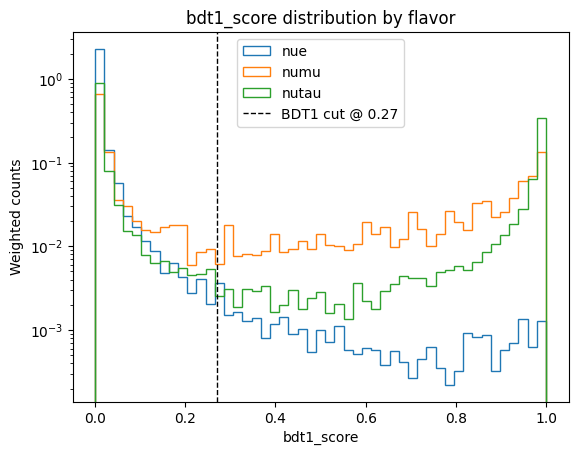

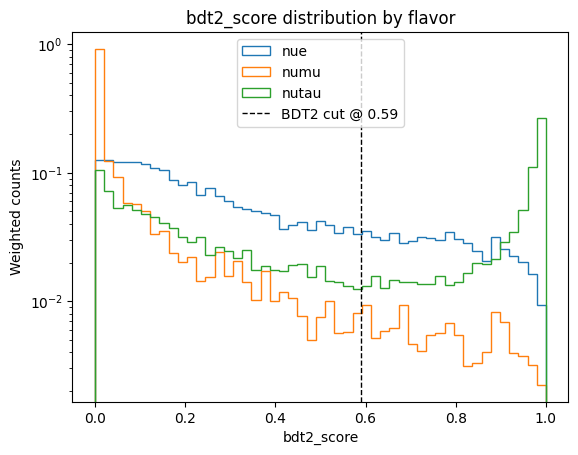

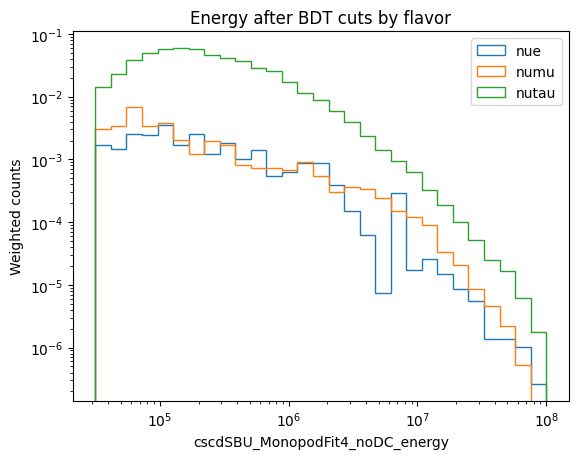


Final purity: 0.900, efficiency: 0.323


In [26]:
from analysis_tools.workflows.evaluation_flow import evaluation_flow

df_eval = df_with_scores

summary = evaluation_flow(
    df_eval, 
    model1 = bdt1,
    model2 = bdt2, 
    features = features_list,
    weight_col = 'weight',
    precut_criteria=precut_dict,
    purity_target=0.90,
    output_dir='/data/user/tvaneede/GlobalFit/reco_processing/bdt/training/zheyang/'
)

compare the roc curves

In [27]:
import matplotlib.pyplot as plt


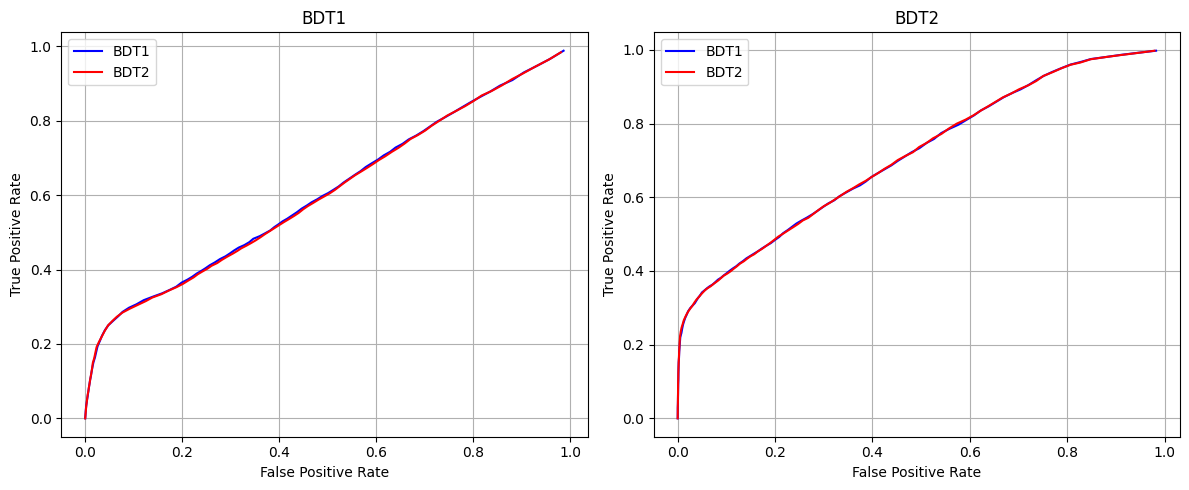

In [28]:
# Read CSVs
zheyang_path = "/data/user/tvaneede/GlobalFit/reco_processing/bdt/training/zheyang/"
roc1_zheyang = pd.read_csv( zheyang_path + "roc_curve1.csv" )
roc2_zheyang = pd.read_csv( zheyang_path + "roc_curve2.csv" )

thijs_path = "/data/user/tvaneede/GlobalFit/reco_processing/bdt/training/retraining_thijs/"
roc1_thijs = pd.read_csv( thijs_path + "roc_curve1.csv" )
roc2_thijs = pd.read_csv( thijs_path + "roc_curve2.csv" )

# Create side-by-side plots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot first iteration
axes[0].plot(roc1_zheyang['fpr'], roc1_zheyang['tpr'], label='BDT1', color='blue')
axes[0].plot(roc1_thijs['fpr'], roc1_thijs['tpr'], label='BDT2', color='red')
axes[0].set_title('BDT1')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend()
axes[0].grid(True)

# Plot second iteration
axes[1].plot(roc2_zheyang['fpr'], roc2_zheyang['tpr'], label='BDT1', color='blue')
axes[1].plot(roc2_thijs['fpr'], roc2_thijs['tpr'], label='BDT2', color='red')
axes[1].set_title('BDT2')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

They are very very comparable!